# Crop Recommendation System based on Soil and Weather Data
## Using Random Forest, Gradient Boosting, XGBoost & Neural Networks
This notebook builds a machine learning system to recommend crops based solely on soil and weather data. It learns the environmental conditions suitable for different crops and predicts the best crop for a given location.

## 1. Import Libraries and Load Data

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
import glob
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import joblib

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# ⚡ GLOBAL GPU SETUP
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  PyTorch Device: {device}")

# Define base path
data_path = Path(r'c:\Users\tanis\Documents\Project 2\Project---2\Data')
print(f"Data path: {data_path}")

🖥️  PyTorch Device: cpu
Data path: c:\Users\tanis\Documents\Project 2\Project---2\Data


## 2. Load and Prepare Environmental Data

In [54]:
# Load all district soil data
soil_path = data_path / 'Soil Data ( District Wise)' / 'CSV Format'
soil_files = glob.glob(str(soil_path / '*.csv'))
soil_df_list = [pd.read_csv(f) for f in soil_files]
soil_data_all = pd.concat(soil_df_list, ignore_index=True)

# Aggregate soil data by district
soil_summary = soil_data_all.groupby('District')[[
    'n_High', 'n_Medium', 'n_Low',
    'p_High', 'p_Medium', 'p_Low',
    'k_High', 'k_Medium', 'k_Low',
    'pH_Neutral', 'pH_Acidic', 'pH_Alkaline',
    'EC_Saline', 'EC_NonSaline',
    'OC_High', 'OC_Medium', 'OC_Low'
]].mean().reset_index()
soil_summary['District'] = soil_summary['District'].str.upper()
print(f"Soil data loaded and aggregated for {len(soil_summary)} districts.")

# Load and aggregate weather data by district
weather_file = data_path / 'Weather Data (District Wise)' / 'weather_data_all_blocks.csv'
weather_data_all = pd.read_csv(weather_file)
weather_summary = weather_data_all.groupby('district')[[
    'temp_max_mean', 'temp_min_mean', 'temp_mean_annual',
    'total_rainfall_mm', 'avg_daily_rainfall_mm',
    'humidity_max_mean', 'humidity_min_mean',
    'rainy_days', 'wind_speed_max_mean'
]].mean().reset_index()
weather_summary.rename(columns={'district': 'District'}, inplace=True)
weather_summary['District'] = weather_summary['District'].str.upper()
print(f"Weather data loaded and aggregated for {len(weather_summary)} districts.")

# Merge soil and weather data
environmental_data = pd.merge(soil_summary, weather_summary, on='District', how='inner')
print(f"\nMerged environmental data shape: {environmental_data.shape}")
environmental_data.head()

Soil data loaded and aggregated for 9 districts.
Weather data loaded and aggregated for 9 districts.

Merged environmental data shape: (9, 27)


,District,n_High,n_Medium,n_Low,p_High,p_Medium,p_Low,k_High,k_Medium,k_Low,...,OC_Low,temp_max_mean,temp_min_mean,temp_mean_annual,total_rainfall_mm,avg_daily_rainfall_mm,humidity_max_mean,humidity_min_mean,rainy_days,wind_speed_max_mean
0,ARIYALUR,0.013333,0.018333,99.968333,2.176667,97.710000,0.110000,0.013333,99.831667,0.156667,...,95.000000,33.066883,24.104367,28.011783,1197.166667,3.270950,89.222650,47.960833,208.333333,19.458017
1,KANNIYAKUMARI,0.000000,89.666667,354.111111,299.222222,95.666667,48.888889,72.555556,282.000000,89.444444,...,249.888889,30.503033,22.907400,26.069133,2021.822222,5.524111,92.832711,58.837311,283.333333,18.594933
2,NAGAPATTINAM,0.026667,3.566667,96.406667,20.681667,39.780000,39.538333,32.616667,51.910000,15.475000,...,64.361667,31.928850,24.670533,27.881867,1710.000000,4.672133,92.707667,57.245000,259.666667,18.513783
3,RAMANATHAPURAM,0.082727,0.005455,99.911818,20.894545,75.590000,3.514545,87.000909,10.921818,2.079091,...,99.940000,33.272218,24.835964,28.434382,1410.454545,3.853700,88.475155,49.706173,254.636364,21.109564
4,THANJAVUR,0.013571,0.260714,99.726429,6.068571,18.387857,75.544286,26.740000,49.789286,23.466429,...,63.349286,32.439779,24.267143,27.765000,1412.035714,3.858029,91.387779,52.704343,235.071429,18.904993


## 3. Create Training Dataset from Crop Location Data
This step creates the ground truth for our model. We use the market data to identify which crops have been grown in which districts. The features will be the environmental data for a district, and the label will be the crop grown there.

In [55]:
# Load all crop CSVs to determine which crops grow in which districts
crop_files = glob.glob(str(data_path / '3_Cleaned CSVs' / '*.csv'))
crop_location_records = []

for file in crop_files:
    crop_name = Path(file).stem
    try:
        df = pd.read_csv(file)
        # Get unique districts where this crop was traded
        districts_grown = df['District Name'].unique()
        for district in districts_grown:
            crop_location_records.append({'Crop': crop_name, 'District': str(district).upper()})
    except Exception as e:
        print(f"Could not process {file}: {e}")

# Create a DataFrame of crop-district pairs
crop_locations = pd.DataFrame(crop_location_records)
print(f"Created {len(crop_locations)} crop-district location records.")

# Merge with environmental data to create the final training dataset
training_df = pd.merge(crop_locations, environmental_data, on='District', how='inner')

print(f"Final training dataset shape: {training_df.shape}")
print(f"Number of unique crops: {training_df['Crop'].nunique()}")
print(f"Number of unique districts: {training_df['District'].nunique()}")
training_df.head()

Created 647 crop-district location records.
Final training dataset shape: (84, 28)
Number of unique crops: 25
Number of unique districts: 5


,Crop,District,n_High,n_Medium,n_Low,p_High,p_Medium,p_Low,k_High,k_Medium,...,OC_Low,temp_max_mean,temp_min_mean,temp_mean_annual,total_rainfall_mm,avg_daily_rainfall_mm,humidity_max_mean,humidity_min_mean,rainy_days,wind_speed_max_mean
0,Bajra,ARIYALUR,0.013333,0.018333,99.968333,2.176667,97.710000,0.110000,0.013333,99.831667,...,95.000000,33.066883,24.104367,28.011783,1197.166667,3.270950,89.222650,47.960833,208.333333,19.458017
1,Bajra,RAMANATHAPURAM,0.082727,0.005455,99.911818,20.894545,75.590000,3.514545,87.000909,10.921818,...,99.940000,33.272218,24.835964,28.434382,1410.454545,3.853700,88.475155,49.706173,254.636364,21.109564
2,Banana - Green,ARIYALUR,0.013333,0.018333,99.968333,2.176667,97.710000,0.110000,0.013333,99.831667,...,95.000000,33.066883,24.104367,28.011783,1197.166667,3.270950,89.222650,47.960833,208.333333,19.458017
3,Banana - Green,THANJAVUR,0.013571,0.260714,99.726429,6.068571,18.387857,75.544286,26.740000,49.789286,...,63.349286,32.439779,24.267143,27.765000,1412.035714,3.858029,91.387779,52.704343,235.071429,18.904993
4,Banana - Green,NAGAPATTINAM,0.026667,3.566667,96.406667,20.681667,39.780000,39.538333,32.616667,51.910000,...,64.361667,31.928850,24.670533,27.881867,1710.000000,4.672133,92.707667,57.245000,259.666667,18.513783


## 3a. Analyze and Filter Data by Crop Frequency
To improve model stability and performance, we will remove crops that have very few data points. Training on classes with only a handful of samples can lead to overfitting and unreliable evaluation metrics.


Original number of unique crops: 25
Number of unique crops after filtering: 15
Removed 10 crops with fewer than 3 samples.
Reduced dataset from 84 to 69 records.


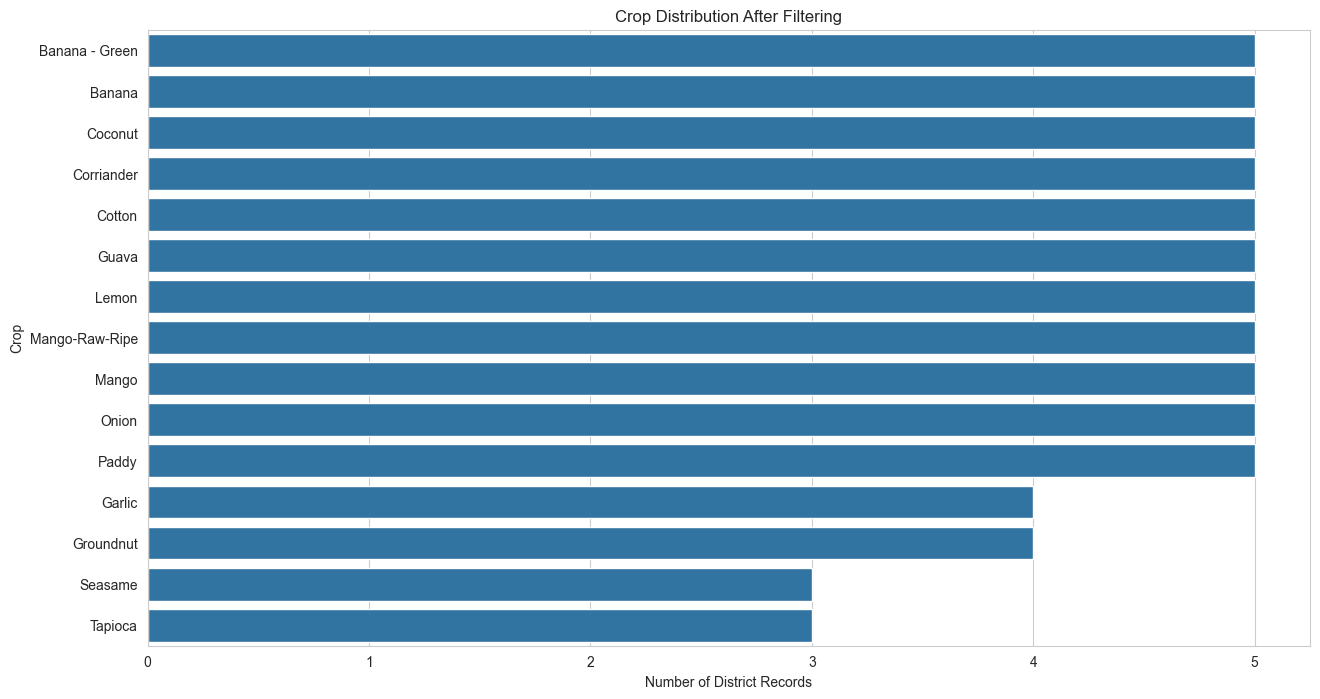

In [56]:
# Analyze the frequency of each crop
crop_counts = training_df['Crop'].value_counts()

# Set a threshold for the minimum number of samples required for a crop to be included
MIN_SAMPLES = 3  # We require at least 3 samples to ensure stable splitting

# Identify crops that meet the threshold
crops_to_keep = crop_counts[crop_counts >= MIN_SAMPLES].index

# Filter the training DataFrame
original_rows = len(training_df)
training_df_filtered = training_df[training_df['Crop'].isin(crops_to_keep)]
filtered_rows = len(training_df_filtered)

print(f"Original number of unique crops: {training_df['Crop'].nunique()}")
print(f"Number of unique crops after filtering: {training_df_filtered['Crop'].nunique()}")
print(f"Removed {training_df['Crop'].nunique() - training_df_filtered['Crop'].nunique()} crops with fewer than {MIN_SAMPLES} samples.")
print(f"Reduced dataset from {original_rows} to {filtered_rows} records.")

# Display the new distribution
plt.figure(figsize=(15, 8))
sns.countplot(y='Crop', data=training_df_filtered, order=training_df_filtered['Crop'].value_counts().index)
plt.title('Crop Distribution After Filtering')
plt.xlabel('Number of District Records')
plt.ylabel('Crop')
plt.show()

# Use the filtered dataframe for training
training_df = training_df_filtered


## 4. Prepare Data for Multiclass Classification
The goal is to predict the `Crop` (the label) from the environmental features.

In [57]:
# Define features (X) and target (y)
features = training_df.drop(columns=['Crop', 'District'])
target = training_df['Crop']

# Encode the crop names into numerical labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(target)

# Save the mapping from encoded label to crop name
crop_mapping = {index: label for index, label in enumerate(label_encoder.classes_)}
print(f"Encoded {len(crop_mapping)} crops into numerical labels.")

# Split data into training and testing sets
# Ensure the test set has at least one sample per class for stratified splitting
test_size = max(len(crop_mapping), int(np.ceil(len(features) * 0.2)))

X_train, X_test, y_train, y_test = train_test_split(
    features, y_encoded, test_size=test_size, random_state=42, stratify=y_encoded
)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTraining set shape: {X_train_scaled.shape}")
print(f"Test set shape: {X_test_scaled.shape}")

Encoded 15 crops into numerical labels.

Training set shape: (54, 26)
Test set shape: (15, 26)


## 5. Train and Evaluate Models
We will train four different models for this multiclass classification task.

### 5.1. Random Forest Classifier

In [58]:
print("Training Random Forest Classifier...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf_model.fit(X_train_scaled, y_train)

# Predictions and Evaluation
y_pred_rf = rf_model.predict(X_test_scaled)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"\nRandom Forest Accuracy: {accuracy_rf:.3f}")
print("\nClassification Report (Random Forest):")
# Display report for a subset of classes for brevity
target_names_subset = [crop_mapping[i] for i in np.unique(y_test)[:10]]
print(classification_report(y_test, y_pred_rf, labels=np.unique(y_test)[:10], target_names=target_names_subset, zero_division=0))

Training Random Forest Classifier...

Random Forest Accuracy: 0.000

Classification Report (Random Forest):
                precision    recall  f1-score   support

        Banana       0.00      0.00      0.00       1.0
Banana - Green       0.00      0.00      0.00       1.0
       Coconut       0.00      0.00      0.00       1.0
    Corriander       0.00      0.00      0.00       1.0
        Cotton       0.00      0.00      0.00       1.0
        Garlic       0.00      0.00      0.00       1.0
     Groundnut       0.00      0.00      0.00       1.0
         Guava       0.00      0.00      0.00       1.0
         Lemon       0.00      0.00      0.00       1.0
         Mango       0.00      0.00      0.00       1.0

     micro avg       0.00      0.00      0.00      10.0
     macro avg       0.00      0.00      0.00      10.0
  weighted avg       0.00      0.00      0.00      10.0



### 5.2. Gradient Boosting Classifier

In [59]:
print("Training Gradient Boosting Classifier...")
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
gb_model.fit(X_train_scaled, y_train)

# Predictions and Evaluation
y_pred_gb = gb_model.predict(X_test_scaled)
accuracy_gb = accuracy_score(y_test, y_pred_gb)
print(f"\nGradient Boosting Accuracy: {accuracy_gb:.3f}")

Training Gradient Boosting Classifier...

Gradient Boosting Accuracy: 0.000


### 5.3. XGBoost Classifier

In [60]:
print("Training XGBoost Classifier...")
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    objective='multi:softmax',
    num_class=len(crop_mapping),
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)
xgb_model.fit(X_train_scaled, y_train)

# Predictions and Evaluation
y_pred_xgb = xgb_model.predict(X_test_scaled)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"\nXGBoost Accuracy: {accuracy_xgb:.3f}")

Training XGBoost Classifier...

XGBoost Accuracy: 0.000


### 5.4. Neural Network (PyTorch)

In [61]:
# Define PyTorch Neural Network for multiclass classification
class CropNN(nn.Module):
    def __init__(self, input_size, num_classes):
        super(CropNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.dropout1 = nn.Dropout(0.4)
        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.dropout2 = nn.Dropout(0.4)
        self.fc3 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = torch.relu(self.bn1(self.fc1(x)))
        x = self.dropout1(x)
        x = torch.relu(self.bn2(self.fc2(x)))
        x = self.dropout2(x)
        # No softmax here, as CrossEntropyLoss applies it internally
        x = self.fc3(x)
        return x

# Prepare PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_scaled).to(device)
y_train_tensor = torch.LongTensor(y_train).to(device)
X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)
y_test_tensor = torch.LongTensor(y_test).to(device)

# Create data loaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Initialize model
input_dim = X_train_scaled.shape[1]
output_dim = len(crop_mapping)
nn_model = CropNN(input_dim, output_dim).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(nn_model.parameters(), lr=0.001)

# Training loop
print("Training Neural Network...")
epochs = 50
for epoch in range(epochs):
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = nn_model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

# Predictions and Evaluation
with torch.no_grad():
    outputs = nn_model(X_test_tensor)
    _, y_pred_nn = torch.max(outputs, 1)
    y_pred_nn = y_pred_nn.cpu().numpy()

accuracy_nn = accuracy_score(y_test, y_pred_nn)
print(f"\nNeural Network Accuracy: {accuracy_nn:.3f}")

Training Neural Network...
Epoch [10/50], Loss: 2.7081
Epoch [20/50], Loss: 2.5549
Epoch [30/50], Loss: 2.6874
Epoch [40/50], Loss: 2.5907
Epoch [50/50], Loss: 2.6440

Neural Network Accuracy: 0.000


## 6. Model Comparison and Recommendation

In [62]:
# Compare all models
models_comparison = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting', 'XGBoost', 'Neural Network'],
    'Accuracy': [accuracy_rf, accuracy_gb, accuracy_xgb, accuracy_nn]
})

print("="*50)
print("MODEL COMPARISON")
print("="*50)
print(models_comparison.sort_values('Accuracy', ascending=False).to_string(index=False))

# Select the best model (highest accuracy)
best_model_name = models_comparison.sort_values('Accuracy', ascending=False).iloc[0]['Model']
if best_model_name == 'Random Forest':
    best_model = rf_model
elif best_model_name == 'Gradient Boosting':
    best_model = gb_model
elif best_model_name == 'XGBoost':
    best_model = xgb_model
else: # Neural Network is more complex to use directly, so we default to RF if it's best
    best_model = rf_model
    best_model_name = "Random Forest (Fallback)"


print(f"\nSelected Best Model for Recommendations: {best_model_name}")

MODEL COMPARISON
            Model  Accuracy
    Random Forest       0.0
Gradient Boosting       0.0
          XGBoost       0.0
   Neural Network       0.0

Selected Best Model for Recommendations: Random Forest


### Make Recommendations for a Target District (e.g., Thanjavur)

In [63]:
# Get environmental data for Thanjavur
target_district = 'THANJAVUR'
thanjavur_env_data = environmental_data[environmental_data['District'] == target_district]

if not thanjavur_env_data.empty:
    # Prepare the data for prediction
    thanjavur_features = thanjavur_env_data.drop(columns=['District'])
    thanjavur_scaled = scaler.transform(thanjavur_features)

    # Predict probabilities for all crops
    if best_model_name != "Neural Network":
        probabilities = best_model.predict_proba(thanjavur_scaled)[0]
    else: # Handle NN prediction
        with torch.no_grad():
            nn_input = torch.FloatTensor(thanjavur_scaled).to(device)
            logits = nn_model(nn_input)
            probabilities = torch.softmax(logits, dim=1).cpu().numpy()[0]

    # Create a DataFrame of recommendations
    recommendations = pd.DataFrame({
        'Crop': label_encoder.classes_,
        'Probability': probabilities
    }).sort_values('Probability', ascending=False)

    print(f"\nTOP 10 CROP RECOMMENDATIONS FOR {target_district.title()}")
    print("="*50)
    print(recommendations.head(10).to_string(index=False))

else:
    print(f"Could not find environmental data for district: {target_district}")



TOP 10 CROP RECOMMENDATIONS FOR Thanjavur
          Crop  Probability
        Garlic     0.119682
     Groundnut     0.108774
         Mango     0.089355
    Corriander     0.088862
         Lemon     0.088435
        Cotton     0.081949
       Coconut     0.076262
Banana - Green     0.075943
         Onion     0.073488
        Banana     0.071373


## 7. Save the Best Model and Supporting Files

In [64]:
# Create a directory for the new model
model_dir = Path(r'c:\Users\tanis\Documents\Project 2\Project---2\Models\Soil_Weather_Model')
model_dir.mkdir(exist_ok=True)

# Save the best performing model, the scaler, and the label encoder
joblib.dump(best_model, model_dir / 'best_crop_model.pkl')
joblib.dump(scaler, model_dir / 'feature_scaler.pkl')
joblib.dump(label_encoder, model_dir / 'crop_label_encoder.pkl')

# Save the neural network model if it's not the best but for future use
torch.save(nn_model.state_dict(), model_dir / 'neural_network_model.pt')


print(f"Models and helper files saved to: {model_dir}")
for file in sorted(model_dir.glob('*')):
    print(f"  ✓ {file.name}")

Models and helper files saved to: c:\Users\tanis\Documents\Project 2\Project---2\Models\Soil_Weather_Model
  ✓ best_crop_model.pkl
  ✓ crop_label_encoder.pkl
  ✓ feature_scaler.pkl
  ✓ neural_network_model.pt
